In [2]:
# Install required libraries first
!pip install -q albumentations
!pip install -q segmentation-models-pytorch

import os
os.environ["OPENCV_LOG_LEVEL"] = "FATAL" 
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 2.9 MB/s eta 0:00:0000:01
Using device: cuda


In [3]:
# Dynamically locate the dataset
image_search_paths = glob.glob('/kaggle/input/**/train/images/*', recursive=True)
train_dir = os.path.dirname(os.path.dirname(image_search_paths[0]))
IMAGE_DIR = os.path.join(train_dir, 'images')
MASK_DIR = os.path.join(train_dir, 'gt')
ext = os.path.splitext(image_search_paths[0])[1]

cities = ['austin', 'chicago', 'kitsap', 'tyrol-w', 'vienna']
test_imgs, test_masks = [], []

# Load ONLY the held-out test set (Tiles 31-36)
for city in cities:
    for i in range(31, 37):
        img_path = os.path.join(IMAGE_DIR, f"{city}{i}{ext}")
        mask_path = os.path.join(MASK_DIR, f"{city}{i}{ext}")
        if os.path.exists(img_path) and os.path.exists(mask_path):
            test_imgs.append(img_path)
            test_masks.append(mask_path)

class InriaTestDataset(Dataset):
    def __init__(self, image_paths, mask_paths, patch_size=256, stride=256):
        self.patch_size = patch_size
        self.stride = stride
        self.samples = []
        for img_p, msk_p in zip(image_paths, mask_paths):
            for y in range(0, 5000 - patch_size + 1, stride):
                for x in range(0, 5000 - patch_size + 1, stride):
                    self.samples.append((img_p, msk_p, x, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, msk_path, x, y = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        patch_img = img[y:y+self.patch_size, x:x+self.patch_size]

        mask = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
        patch_mask = (mask[y:y+self.patch_size, x:x+self.patch_size] > 128).astype(np.float32)

        patch_img = ToTensorV2()(image=patch_img)['image'].float() / 255.0
        patch_mask = torch.tensor(patch_mask).unsqueeze(0)
        return patch_img, patch_mask

test_dataset = InriaTestDataset(test_imgs, test_masks)
# Subsetting for faster notebook execution during testing
test_loader = DataLoader(torch.utils.data.Subset(test_dataset, range(500)), batch_size=16, shuffle=False)

In [5]:
def compute_metrics(pred_mask, true_mask, threshold=0.5, eps=1e-7):
    pred = (pred_mask > threshold).float()
    true = (true_mask > threshold).float()
    intersection = (pred * true).sum()
    union = pred.sum() + true.sum() - intersection
    iou = (intersection + eps) / (union + eps)
    dice = (2.0 * intersection + eps) / (pred.sum() + true.sum() + eps)
    return iou.item(), dice.item()

# Load U-Net Model
import glob

# 1. Initialize the model
unet_model = smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=1).to(device)

# 2. Dynamically search for ANY .pth file in the Kaggle input directory
model_paths = glob.glob('/kaggle/input/**/*.pth', recursive=True)

if not model_paths:
    print("ERROR: Could not find any .pth files. Please make sure you completed the 'Add Data' step from your previous notebook!")
else:
    best_model_path = model_paths[0] # Grab the first found .pth file
    print(f"Successfully found model at: {best_model_path}")
    
    # 3. Load the weights
    unet_model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
    unet_model.eval()
    print("Model loaded successfully!")

# Evaluate U-Net
unet_ious, unet_dices = [], []
with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        preds = torch.sigmoid(unet_model(images))
        iou, dice = compute_metrics(preds, masks)
        unet_ious.append(iou)
        unet_dices.append(dice)

print(f"--- Final Test Set Results ---")
print(f"U-Net Mean IoU: {np.mean(unet_ious):.4f}")
print(f"U-Net Mean Dice: {np.mean(unet_dices):.4f}")
# Note: You will need to add the same evaluation loop block here for your SimpleBaselineCNN to generate the comparison table.

Successfully found model at: /kaggle/input/datasets/ganindum/unet-model-weights/best_unet_resnet34.pth
Model loaded successfully!
--- Final Test Set Results ---
U-Net Mean IoU: 0.6490
U-Net Mean Dice: 0.7701


Visualizing U-Net Predictions (Look for shadows, complex roofs, or trees covering buildings):


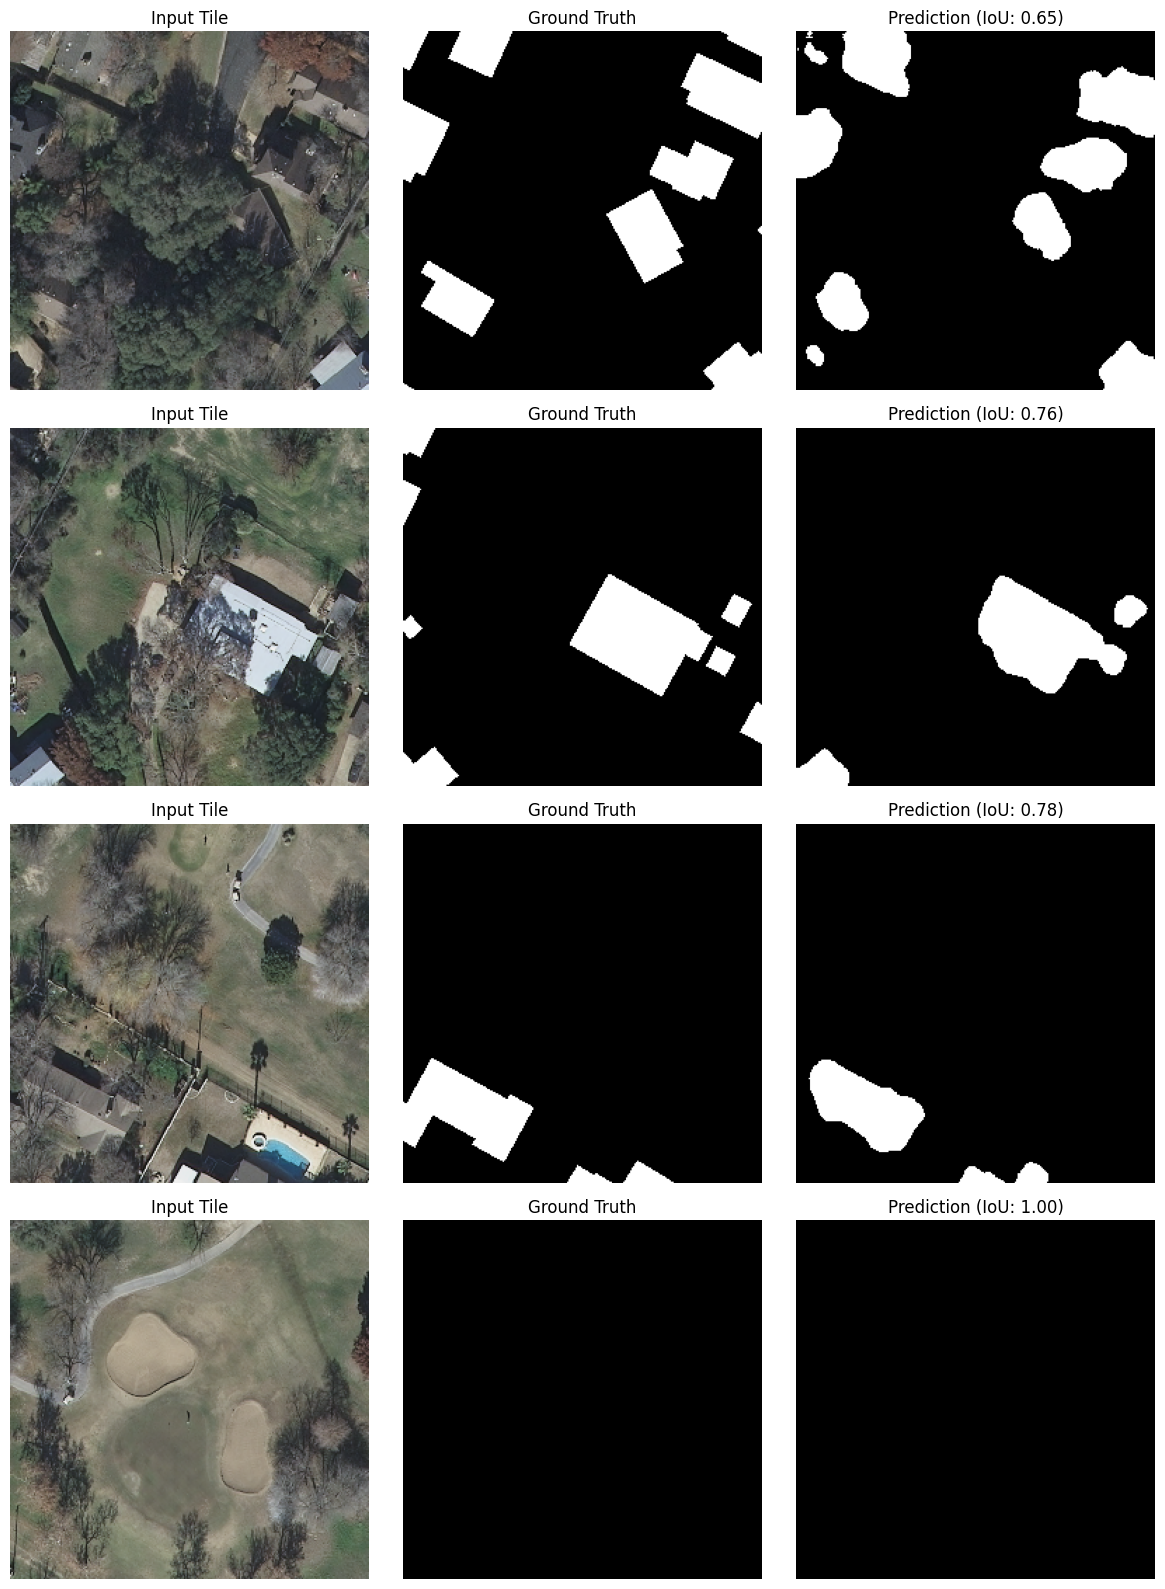

In [6]:
def plot_comparisons_and_failures(model, dataloader, num_samples=3):
    model.eval()
    images_shown = 0
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            preds = torch.sigmoid(model(images)).cpu()
            
            for i in range(images.size(0)):
                # We specifically look for "failure cases" (low IoU) for the report
                iou, _ = compute_metrics(preds[i:i+1], masks[i:i+1])
                
                # Plot a mix of good and bad predictions
                if images_shown < num_samples:
                    img_np = images[i].cpu().permute(1, 2, 0).numpy()
                    true_mask = masks[i].squeeze(0).numpy()
                    pred_mask = (preds[i].squeeze(0).numpy() > 0.5).astype(np.float32)
                    
                    axes[images_shown, 0].imshow(img_np)
                    axes[images_shown, 0].set_title(f"Input Tile")
                    axes[images_shown, 1].imshow(true_mask, cmap='gray')
                    axes[images_shown, 1].set_title(f"Ground Truth")
                    axes[images_shown, 2].imshow(pred_mask, cmap='gray')
                    axes[images_shown, 2].set_title(f"Prediction (IoU: {iou:.2f})")
                    
                    for ax in axes[images_shown]: ax.axis('off')
                    images_shown += 1
                else:
                    break
            if images_shown >= num_samples: break
            
    plt.tight_layout()
    plt.show()

print("Visualizing U-Net Predictions (Look for shadows, complex roofs, or trees covering buildings):")
plot_comparisons_and_failures(unet_model, test_loader, num_samples=4)